In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pip install blpapi xbbg pandas matplotlib



# load your file
df = pd.read_excel("/Users/priyanshuchoudhary/Downloads/cleaned data.xlsx", sheet_name=0, header=2)

# parse dates
df["Dates"] = pd.to_datetime(df["Dates"], errors="coerce")


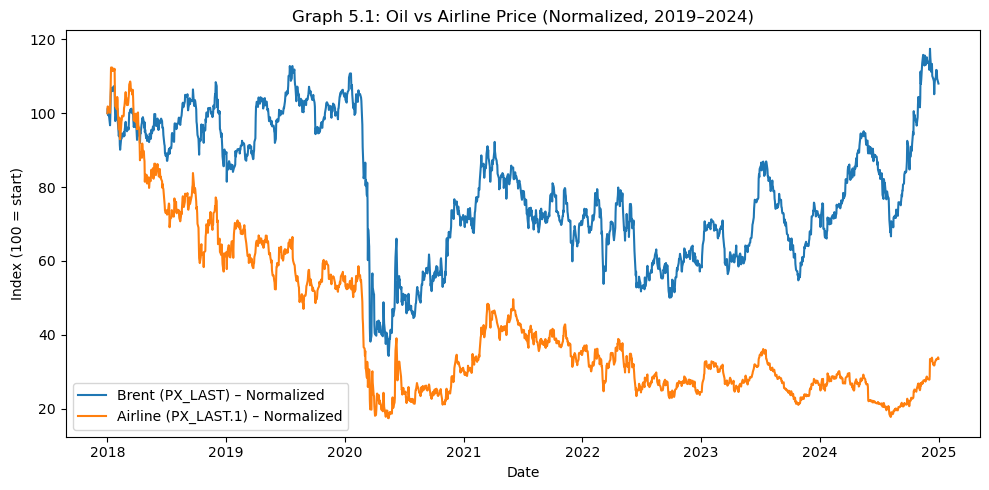

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

# Load full data
df = pd.read_excel("/Users/priyanshuchoudhary/Downloads/cleaned data.xlsx", sheet_name=0, header=2)

# Parse dates
df["Dates"] = pd.to_datetime(df["Dates"])

# Select Brent oil price
oil = pd.to_numeric(df["PX_LAST"], errors="coerce")
air_px = pd.to_numeric(df["PX_LAST.1"], errors="coerce")

# Normalize to start = 100
b_norm = (oil / oil.iloc[0]) * 100
a_norm = (air_px / air_px.iloc[0]) * 100

# Plot
plt.figure(figsize=(10,5))
plt.plot(df["Dates"], b_norm, label="Brent (PX_LAST) – Normalized")
plt.plot(df["Dates"], a_norm, label="Airline (PX_LAST.1) – Normalized")
plt.title("Graph 5.1: Oil vs Airline Price (Normalized, 2019–2024)")
plt.xlabel("Date")
plt.ylabel("Index (100 = start)")
plt.legend()
plt.tight_layout()
plt.show()


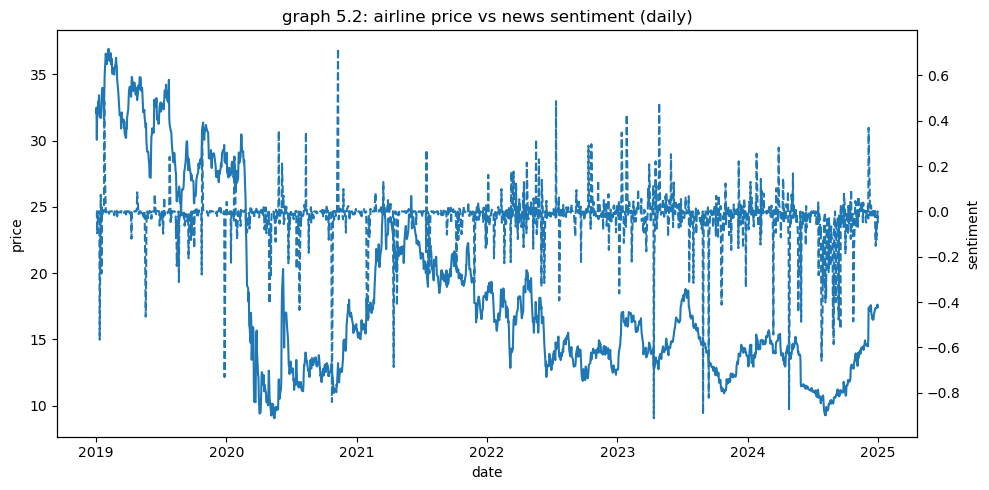

In [109]:

AIR_PX_COL   = "PX_LAST.1"                 # example: the airline you plotted in 5.1
AIR_SENT_COL = "NEWS_SENTIMENT_DAILY_AVG.1"

price = pd.to_numeric(df[AIR_PX_COL], errors="coerce")
sent  = pd.to_numeric(df[AIR_SENT_COL], errors="coerce")

mask = (df["Dates"] >= "2019-01-01") & (df["Dates"] <= "2024-12-31")

plt.figure(figsize=(10,5))
ax = plt.gca()
ax.plot(df["Dates"][mask], price[mask], label=AIR_PX_COL)
ax.set_xlabel("date"); ax.set_ylabel("price")

ax2 = ax.twinx()
ax2.plot(df["Dates"][mask], sent[mask], linestyle="--", label=AIR_SENT_COL)
ax2.set_ylabel("sentiment")

plt.title("graph 5.2: airline price vs news sentiment (daily)")
plt.tight_layout()
plt.show()


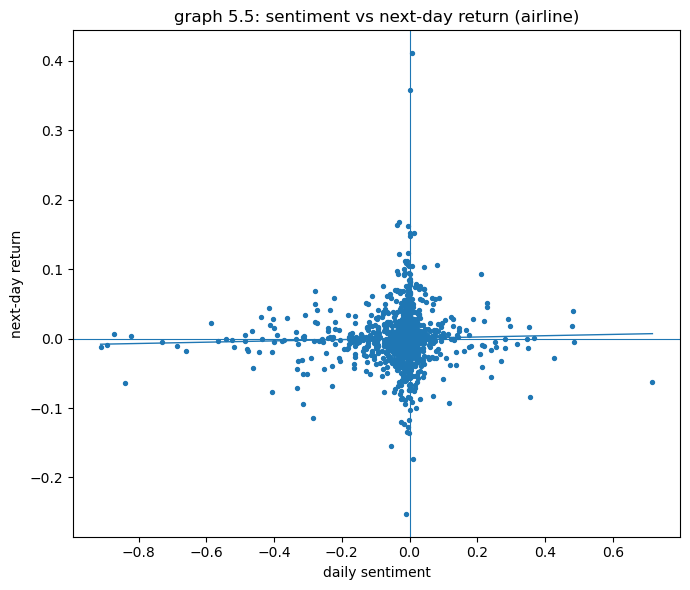

In [110]:

PX_COL   = "PX_LAST.1"
SENT_COL = "NEWS_SENTIMENT_DAILY_AVG.1"

ret_next = pd.to_numeric(df[PX_COL], errors="coerce").pct_change().shift(-1)
sent     = pd.to_numeric(df[SENT_COL], errors="coerce")

mask = (df["Dates"] >= "2019-01-01") & (df["Dates"] <= "2024-12-31")
x = sent[mask]; y = ret_next[mask]
valid = x.notna() & y.notna()

xv, yv = x[valid].values, y[valid].values
plt.figure(figsize=(7,6))
plt.scatter(xv, yv, s=8)
plt.axhline(0, linewidth=0.8); plt.axvline(0, linewidth=0.8)
plt.xlabel("daily sentiment")
plt.ylabel("next-day return")
plt.title("graph 5.5: sentiment vs next-day return (airline)")


if len(xv) > 10:
    m, c = np.polyfit(xv, yv, 1)
    xs = np.linspace(xv.min(), xv.max(), 100)
    plt.plot(xs, m*xs + c, linewidth=1)

plt.tight_layout()
plt.show()


In [111]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Output folder
OUT = Path("./exports_section6")
OUT.mkdir(parents=True, exist_ok=True)


Using columns: ['PX_LAST', 'PX_LAST.1', 'PX_LAST.2']


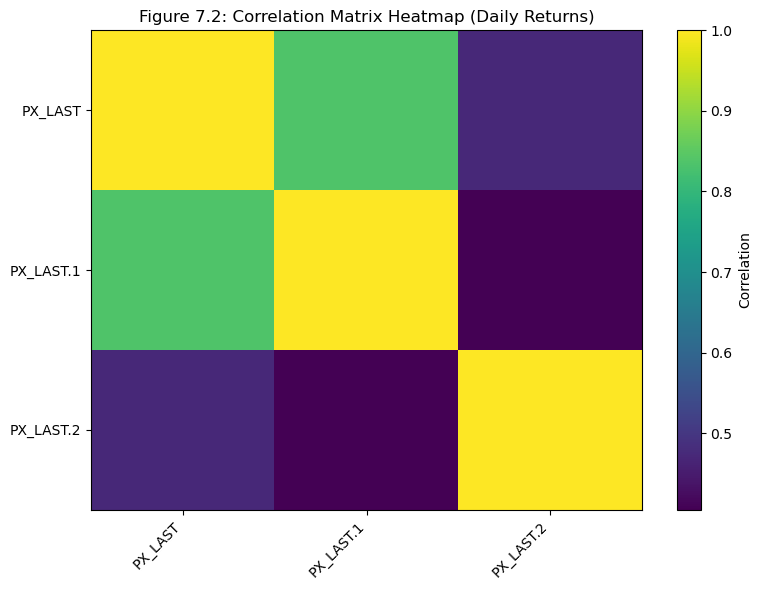

Saved to: /Users/priyanshuchoudhary/figure_7_2_heatmap.png


In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# load your file (first sheet; header row is 3rd line in a typical Bloomberg export)
df = pd.read_excel("/Users/priyanshuchoudhary/Downloads/cleaned data.xlsx", sheet_name=0, header=2)
if "Dates" in df.columns:
    df["Dates"] = pd.to_datetime(df["Dates"], errors="coerce")

# auto-detect columns 
cols = [str(c) for c in df.columns]

# likely oil columns (Brent/WTI/Heating Oil/Comdty)
oil_candidates = [c for c in cols if any(k in c.lower() for k in ["co1", "cl1", "ho1", "brent", "wti", "comdty", "oil"])]

# airline price columns from Spreadsheet Builder 
air_px_cols = [c for c in cols if c.startswith("PX_LAST")]

# pick up to 3 airlines + up to 2 oils to keep the heatmap readable
chosen = []
chosen += oil_candidates[:2]
chosen += air_px_cols[:3]

# sanity check
if len(chosen) < 2:
    raise ValueError(
        "Not enough columns detected. "
        "Print df.columns to confirm names and adjust the filters."
    )

print("Using columns:", chosen)

# build returns panel 
panel = df[chosen].apply(pd.to_numeric, errors="coerce")
returns = panel.pct_change()

# drop rows that are all NaN (e.g., the first row after pct_change)
returns = returns.dropna(how="all")

# compute correlation matrix
corr = returns.corr(min_periods=60)
labels = corr.columns.tolist()
C = corr.values

# plot heatmap (matplotlib only)
plt.figure(figsize=(8,6))
im = plt.imshow(C, interpolation="nearest", aspect="auto")
plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)
cbar = plt.colorbar(im)
cbar.set_label("Correlation", rotation=90)

plt.title("Figure 7.2: Correlation Matrix Heatmap (Daily Returns)")
plt.tight_layout()

# save if you want a file for Word
out = Path("./figure_7_2_heatmap.png")
plt.savefig(out, dpi=200)
plt.show()

print(f"Saved to: {out.resolve()}")


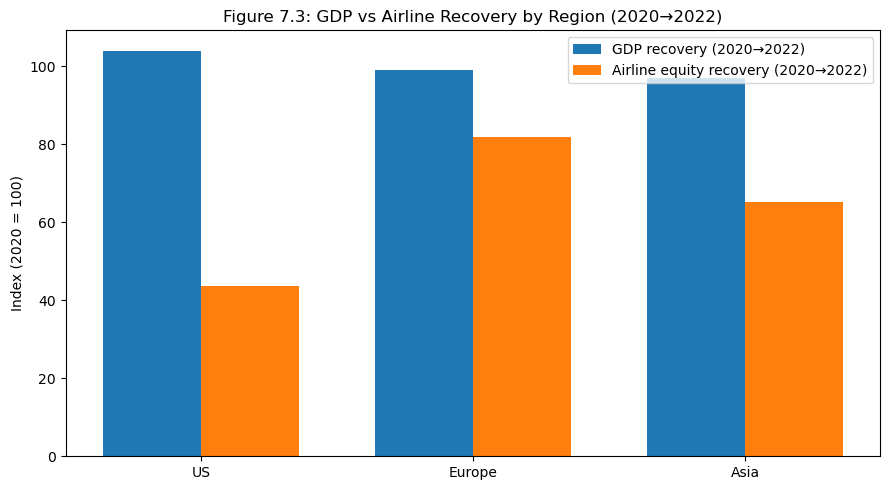

Saved to: /Users/priyanshuchoudhary/figure_7_3_gdp_vs_airlines.png


In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load your data 
df = pd.read_excel("/Users/priyanshuchoudhary/Downloads/cleaned data.xlsx", sheet_name=0, header=2)
assert "Dates" in df.columns, "Expected a 'Dates' column."
df["Dates"] = pd.to_datetime(df["Dates"], errors="coerce")
dates = df["Dates"]

# EDIT: GDP recovery index (2022 vs 2020 = 100 baseline)
GDP_RECOVERY = {
    "US":     104,   # replace with your actual value
    "Europe":  99,
    "Asia":    97
}

# EDIT: Map regions to airline price columns from your sheet
REGION_AIRLINES = {
    "US":     ["PX_LAST.1"],   # e.g., Delta
    "Europe": ["PX_LAST.2"],   # e.g., Lufthansa
    "Asia":   ["PX_LAST.3"]    # e.g., Singapore Airlines
}

start_date = pd.Timestamp("2020-01-02")
end_date   = pd.Timestamp("2022-12-30")

def recovery_index(px_series, index_dates, d0, d1):
    """
    Return (price at nearest d1 / price at nearest d0) * 100.
    Uses scalar integer positions with .iloc to avoid the multidimensional index error.
    """
    s = pd.to_numeric(px_series, errors="coerce")
    s = pd.Series(s.values, index=index_dates).sort_index()

    # positions of nearest dates
    pos0 = s.index.get_indexer([d0], method="nearest")[0]
    pos1 = s.index.get_indexer([d1], method="nearest")[0]

    base = float(s.iloc[pos0])
    endv = float(s.iloc[pos1])

    if np.isnan(base) or base == 0 or np.isnan(endv):
        return np.nan
    return (endv / base) * 100.0

# compute airline recovery per region (average if multiple tickers)
airline_recovery = {}
for region, cols in REGION_AIRLINES.items():
    vals = []
    for col in cols:
        if col in df.columns:
            vals.append(recovery_index(df[col], dates, start_date, end_date))
        else:
            print(f"Warning: {col} not found for {region}; skipping.")
    airline_recovery[region] = np.nanmean(vals) if vals else np.nan

# Build chart
regions = ["US", "Europe", "Asia"]
gdp_vals = [GDP_RECOVERY.get(r, np.nan) for r in regions]
air_vals = [airline_recovery.get(r, np.nan) for r in regions]

x = np.arange(len(regions))
w = 0.36

plt.figure(figsize=(9,5))
plt.bar(x - w/2, gdp_vals, width=w, label="GDP recovery (2020→2022)")
plt.bar(x + w/2, air_vals, width=w, label="Airline equity recovery (2020→2022)")

plt.xticks(x, regions)
plt.ylabel("Index (2020 = 100)")
plt.title("Figure 7.3: GDP vs Airline Recovery by Region (2020→2022)")
plt.legend()
plt.tight_layout()

out = Path("./figure_7_3_gdp_vs_airlines.png")
plt.savefig(out, dpi=200)
plt.show()
print(f"Saved to: {out.resolve()}")


Correlation (r): 0.087  |  Slope: 0.0287


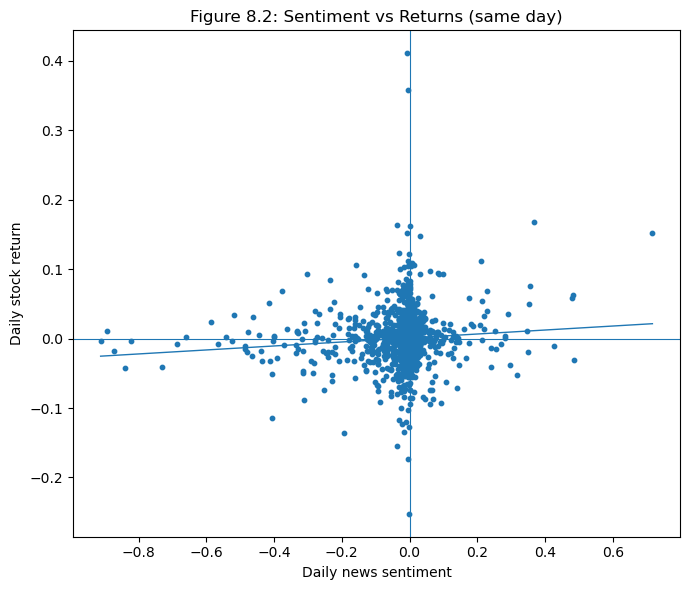

Saved: /Users/priyanshuchoudhary/figure_8_2_scatter_sentiment_vs_return.png


In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load 
df = pd.read_excel("/Users/priyanshuchoudhary/Downloads/cleaned data.xlsx", sheet_name=0, header=2)
df["Dates"] = pd.to_datetime(df["Dates"], errors="coerce")

# === EDIT THESE TWO to the airline you want ===
AIR_PX_COL   = "PX_LAST.1"                 # e.g., Delta (first airline after the oil column in your sheet)
AIR_SENT_COL = "NEWS_SENTIMENT_DAILY_AVG.1"

# Build series 
price = pd.to_numeric(df[AIR_PX_COL], errors="coerce")
sent  = pd.to_numeric(df[AIR_SENT_COL], errors="coerce")

# returns: contemporaneous (same day). For next-day predictive, set NEXT_DAY=True.
NEXT_DAY = False
ret = price.pct_change()
if NEXT_DAY:
    ret = ret.shift(-1)  # sentiment today vs return tomorrow

# date window
mask = (df["Dates"] >= "2019-01-01") & (df["Dates"] <= "2024-12-31")

x = sent[mask]
y = ret[mask]
valid = x.notna() & y.notna()
xv, yv = x[valid].values, y[valid].values

# Plot
plt.figure(figsize=(7,6))
plt.scatter(xv, yv, s=10)
plt.axhline(0, linewidth=0.8); plt.axvline(0, linewidth=0.8)
plt.xlabel("Daily news sentiment")
ylabel = "Daily stock return" if not NEXT_DAY else "Next-day stock return"
plt.ylabel(ylabel)
title = "Figure 8.2: Sentiment vs Returns (same day)" if not NEXT_DAY else "Figure 8.2: Sentiment vs Next-Day Returns"
plt.title(title)

# optional fit line + simple R
if len(xv) > 10:
    m, c = np.polyfit(xv, yv, 1)
    xs = np.linspace(xv.min(), xv.max(), 200)
    plt.plot(xs, m*xs + c, linewidth=1)
    r = np.corrcoef(xv, yv)[0,1]
    print(f"Correlation (r): {r:.3f}  |  Slope: {m:.4f}")

plt.tight_layout()

# save file for Word
out = Path("./figure_8_2_scatter_sentiment_vs_return.png") if not NEXT_DAY else Path("./figure_8_2_scatter_sentiment_vs_nextday.png")
plt.savefig(out, dpi=200)
plt.show()
print(f"Saved: {out.resolve()}")
